Dataset Overview

This analysis uses RNA-seq expression data from GEO (GSE60424), containing normalized gene expression profiles across multiple immune cell types.

The objective is to explore global transcriptional structure and identify patterns of similarity between samples.

In [14]:
import pandas as pd
import numpy as np
import gzip
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

file_path = "../data/raw/GSE60424_GEOSubmit_FC1to11_normalized_counts.txt.gz"
series_matrix = "../data/raw/GSE60424_series_matrix.txt.gz"

In [15]:
#Select data#
prefixes = (
    "!Sample_characteristics_ch1",
    "!Sample_title",
    "!Sample_geo_accession",
    "!Sample_source_name_ch1",
    "!Sample_organism_ch1",
)

rows = []

with gzip.open(series_matrix, "rt", encoding="utf-8") as f:
    for line in f:
        if line.startswith(prefixes):
            rows.append(line.strip().split("\t"))

sm = pd.DataFrame(rows)

sm.head()

,0,1,2,3,4,5,6,7,8,9,...,125,126,127,128,129,130,131,132,133,134
0,!Sample_title,"""lib221""","""lib222""","""lib223""","""lib224""","""lib225""","""lib226""","""lib227""","""lib228""","""lib229""",...,"""lib346""","""lib347""","""lib348""","""lib349""","""lib350""","""lib351""","""lib352""","""lib353""","""lib354""","""lib355"""
1,!Sample_geo_accession,"""GSM1479433""","""GSM1479434""","""GSM1479435""","""GSM1479436""","""GSM1479437""","""GSM1479438""","""GSM1479439""","""GSM1479440""","""GSM1479441""",...,"""GSM1479557""","""GSM1479558""","""GSM1479559""","""GSM1479560""","""GSM1479561""","""GSM1479562""","""GSM1479563""","""GSM1479564""","""GSM1479565""","""GSM1479566"""
2,!Sample_source_name_ch1,"""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""",...,"""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood"""
3,!Sample_organism_ch1,"""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""",...,"""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens"""
4,!Sample_characteristics_ch1,"""age: 32""","""age: 52""","""age: 52""","""age: 24""","""age: 27""","""age: 32""","""age: 32""","""age: 32""","""age: 32""",...,"""age: 35""","""age: 35""","""age: 35""","""age: --""","""age: --""","""age: --""","""age: --""","""age: --""","""age: --""","""age: --"""


In [ ]:
sm = sm.set_index(0)      
sm_t = sm.T   
#Rename
rename_map = {
      "!Sample_title": "title",                                                                                                   
      "!Sample_geo_accession": "geo_accession",                                                                           
      "!Sample_source_name_ch1": "source",                                                                                  
      "!Sample_organism_ch1": "organism",
  }

new_cols = []
for i, col in enumerate(sm_t.columns):
    if col == "!Sample_characteristics_ch1":
        first_val = sm_t.iloc[0, i].strip('"')
        key = first_val.split(":")[0].strip()
        new_cols.append(key)
    elif col in rename_map:
         new_cols.append(rename_map[col])
    else:
        new_cols.append(col)
sm_t.columns = new_cols
#sm_t.columns
        
for col in sm_t.columns:
     if col not in ("title", "geo_accession", "source", "organism"):
         sm_t[col] = sm_t[col].str.strip('"').str.split(":", n=1).str[1].str.strip()
        
sm_t

,title,geo_accession,source,organism,age,cellcount,celltype,collectiondate,diseasestatus,donorid,gender,index,race,samplename,smoker,time since last flare (months),time since steroid dose,time since symptom onset (yrs),years since diagnosis
1,"""lib221""","""GSM1479433""","""Whole Blood""","""Homo sapiens""",32,--,Whole Blood,June 26 2012,Healthy Control,44,F,21,Hispanic,44_Tempus,--,--,--,--,--
2,"""lib222""","""GSM1479434""","""Whole Blood""","""Homo sapiens""",52,--,Whole Blood,May 21 2012,MS pretreatment,31,F,2,White,31_Tempus,Y,1,"3 weeks, oral",1,--
3,"""lib223""","""GSM1479435""","""Whole Blood""","""Homo sapiens""",52,--,Whole Blood,May 22 2012,MS posttreatment,33,F,9,White,33_Tempus,Y,1,"3 weeks, oral",1,--
4,"""lib224""","""GSM1479436""","""Whole Blood""","""Homo sapiens""",24,--,Whole Blood,May 23 2012,Type 1 Diabetes,34,F,13,White,34_Tempus,--,--,--,--,7
5,"""lib225""","""GSM1479437""","""Whole Blood""","""Homo sapiens""",27,--,Whole Blood,June 6 2012,Type 1 Diabetes,37,F,23,White,37_Tempus,--,--,--,--,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,"""lib351""","""GSM1479562""","""Whole Blood""","""Homo sapiens""",--,2000000,B-cells,September 12 2012,ALS,58,,11,--,58_Bcells,--,--,--,--,--
131,"""lib352""","""GSM1479563""","""Whole Blood""","""Homo sapiens""",--,2000000,CD4,September 12 2012,ALS,58,,5,--,58_CD4T,--,--,--,--,--
132,"""lib353""","""GSM1479564""","""Whole Blood""","""Homo sapiens""",--,2000000,CD8,September 12 2012,ALS,58,,20,--,58_CD8T,--,--,--,--,--
133,"""lib354""","""GSM1479565""","""Whole Blood""","""Homo sapiens""",--,1708523,NK,September 12 2012,ALS,58,,25,--,58_NK,--,--,--,--,--


In [17]:
labels = sm_t["celltype"]

In [18]:
df = pd.read_csv(file_path, sep="\t")
df.shape

(50045, 135)

In [19]:
df = df.set_index("genenames")
df.head()

,lib221,lib222,lib223,lib224,lib225,lib226,lib227,lib228,lib229,lib230,...,lib346,lib347,lib348,lib349,lib350,lib351,lib352,lib353,lib354,lib355
genenames,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1,0,1,1,1,0,0,0,2,1,...,1,0,1,0,0,0,1,1,0,0
ENSG00000000005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000419,23,22,25,28,25,41,18,12,14,20,...,28,19,35,37,25,17,22,25,25,30
ENSG00000000457,11,11,14,17,11,32,9,24,19,16,...,18,13,15,26,5,23,17,15,14,14
ENSG00000000460,3,3,3,3,2,4,5,9,4,6,...,11,9,5,4,7,12,8,8,11,5


In [20]:
df.index[:5]
df.index.name = None
df.head()

,lib221,lib222,lib223,lib224,lib225,lib226,lib227,lib228,lib229,lib230,...,lib346,lib347,lib348,lib349,lib350,lib351,lib352,lib353,lib354,lib355
ENSG00000000003,1,0,1,1,1,0,0,0,2,1,...,1,0,1,0,0,0,1,1,0,0
ENSG00000000005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000419,23,22,25,28,25,41,18,12,14,20,...,28,19,35,37,25,17,22,25,25,30
ENSG00000000457,11,11,14,17,11,32,9,24,19,16,...,18,13,15,26,5,23,17,15,14,14
ENSG00000000460,3,3,3,3,2,4,5,9,4,6,...,11,9,5,4,7,12,8,8,11,5


<Axes: >

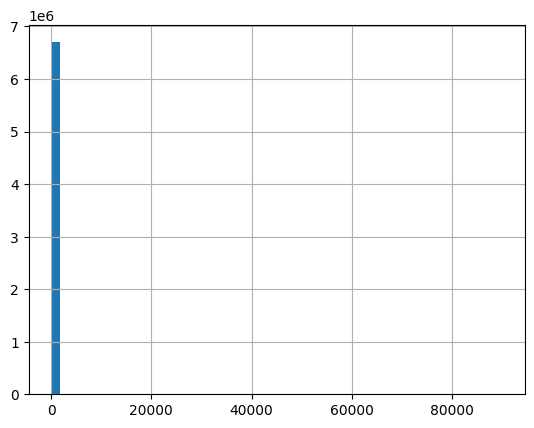

In [21]:
df.iloc[:, :].stack().hist(bins=50)

<Axes: >

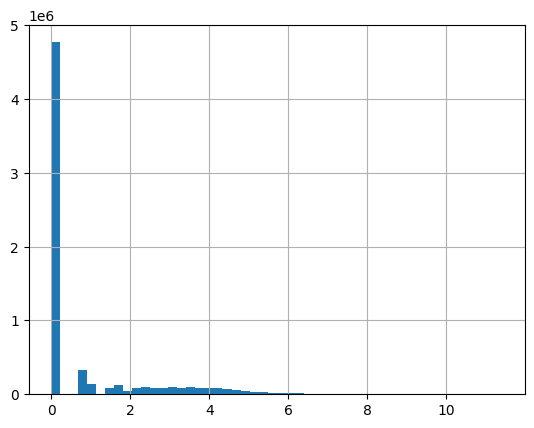

In [22]:
df_log = np.log1p(df)
df_log.stack().hist(bins=50)

In [23]:
counts, bins = np.histogram(df_log.stack(), bins=50)
print(counts)

[4767473       0       0  327243  133059       0   86224  121470   47114
   80461   99559   82339   91400   94235   91198   95174   91261   82324
   78284   65014   57521   46026   36236   28490   23194   18523   14663
   11093    9103    7119    5439    4037    2937    2114    1613    1261
     956     650     449     271     205     126      79      55      21
       8       6       0       2       1]


In [24]:
X = df_log.T
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

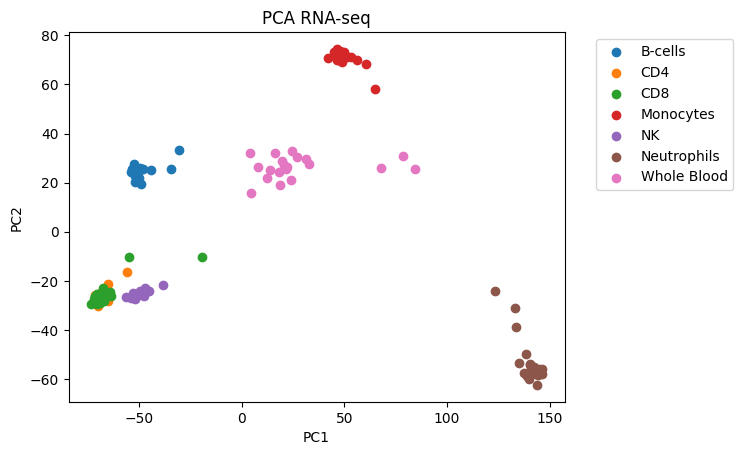

In [25]:
groups = labels.astype("category")

for g in groups.cat.categories:
    idx = groups == g
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=g
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA RNA-seq")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

PCA Analysis

The PCA of gene expression profiles shows a clear separation of immune cell types.

Monocytes cluster distinctly in the upper region of the plot, while B cells are located on the left side at intermediate PC2 values. Neutrophils are separated in the lower right quadrant, suggesting a strong transcriptional divergence from lymphoid populations.

NK cells, CD4 T cells, and CD8 T cells form a closely related cluster in the lower left region, consistent with their shared lymphoid origin.

Whole blood samples are located near the center of the plot, reflecting their heterogeneous cellular composition.

Overall, the first two principal components capture biologically meaningful variation corresponding to immune cell lineage and differentiation state.

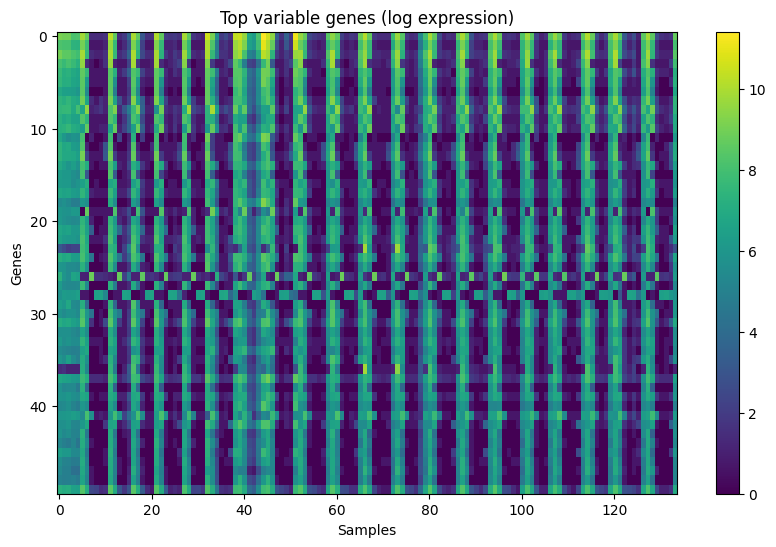

In [26]:
gene_variability = df_log.var(axis=1)
top_genes = gene_variability.sort_values(ascending=False).head(50)
tg = df_log.loc[top_genes.index]

plt.figure(figsize=(10,6))
plt.imshow(tg, aspect='auto')
plt.colorbar()
plt.title("Top variable genes (log expression)")
plt.xlabel("Samples")
plt.ylabel("Genes")
plt.show()


Methods Summary

- Data loading from GEO series matrix
- Log transformation (log1p) of normalized expression values
- Gene-level variance estimation
- PCA for dimensionality reduction and visualization

Biological Interpretation

The observed structure suggests that global gene expression is strongly driven by immune cell identity. Samples cluster according to lineage rather than technical factors, indicating that the dataset captures true biological variation.

Lymphoid cells (B cells, T cells, NK cells) show closer transcriptional similarity compared to myeloid cells (monocytes and neutrophils).